# Import Required Libraries

In [67]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Save trained model
import pickle

# Generate Dataset

In [68]:
# Ensure reproducibility
np.random.seed(42)

# Number of records
n = 1000

# Generate realistic student data
gpa = np.round(np.random.uniform(2.0, 4.0, n), 2)

entrance_score = np.random.randint(40, 100, n)

extracurricular_activities = np.random.randint(0, 6, n)

recommendation_score = np.random.randint(1, 11, n)

# Generate admission label
admission = (
    (gpa >= 3.0) &
    (entrance_score >= 70) &
    (recommendation_score >= 6)
).astype(int)

# Create DataFrame
df = pd.DataFrame({
    "GPA": gpa,
    "Entrance_Score": entrance_score,
    "Extracurricular_Activities": extracurricular_activities,
    "Recommendation_Score": recommendation_score,
    "Admission": admission
})

# Save dataset
df.to_csv("admission_dataset.csv", index=False)

print("Dataset created successfully.")

Dataset created successfully.


# View Dataset

In [69]:
# Display first five rows
df.head()

,GPA,Entrance_Score,Extracurricular_Activities,Recommendation_Score,Admission
0,2.75,86,4,3,0
1,3.90,51,3,1,0
2,3.46,55,2,6,0
3,3.20,63,1,7,0
4,2.31,58,3,2,0


In [70]:
df.columns

Index(['GPA', 'Entrance_Score', 'Extracurricular_Activities',
       'Recommendation_Score', 'Admission'],
      dtype='object')

In [71]:
# Check number of rows and columns
df.shape

(1000, 5)

In [72]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   GPA                         1000 non-null   float64
 1   Entrance_Score              1000 non-null   int32  
 2   Extracurricular_Activities  1000 non-null   int32  
 3   Recommendation_Score        1000 non-null   int32  
 4   Admission                   1000 non-null   int64  
dtypes: float64(1), int32(3), int64(1)
memory usage: 27.5 KB


In [73]:
# Display statistical summary
df.describe()

,GPA,Entrance_Score,Extracurricular_Activities,Recommendation_Score,Admission
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,2.980300,69.50800,2.54100,5.408000,0.126000
std,0.584246,17.27137,1.69741,2.850555,0.332015
min,2.010000,40.00000,0.00000,1.000000,0.000000
25%,2.467500,54.00000,1.00000,3.000000,0.000000
50%,2.990000,69.00000,3.00000,5.000000,0.000000
75%,3.490000,84.25000,4.00000,8.000000,0.000000
max,4.000000,99.00000,5.00000,10.000000,1.000000


# Data Preprocessing

In [74]:
# Check for missing values
df.isnull().sum()

GPA                           0
Entrance_Score                0
Extracurricular_Activities    0
Recommendation_Score          0
Admission                     0
dtype: int64

In [75]:
# Remove duplicate records if any
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully.")

Duplicates removed successfully.


# Admission Distribution

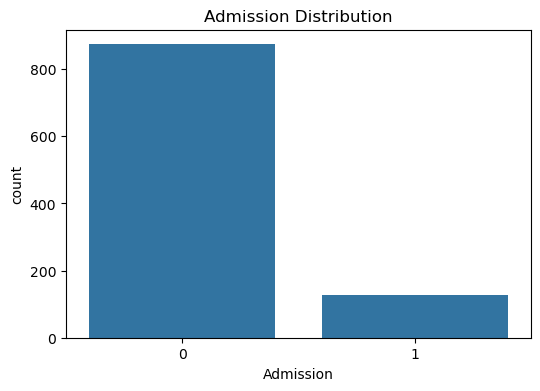

In [76]:
plt.figure(figsize=(6,4))

sns.countplot(x='Admission', data=df)

plt.title("Admission Distribution")

plt.show()

# 1. GPA Distribution

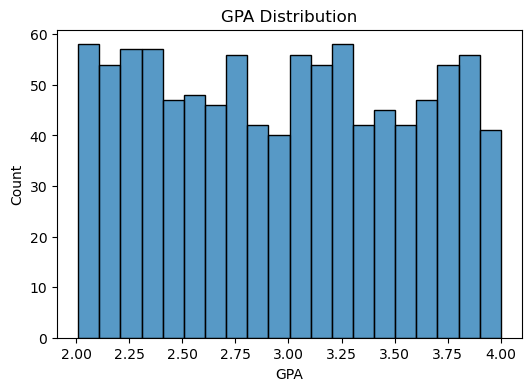

In [77]:
plt.figure(figsize=(6,4))

sns.histplot(df['GPA'], bins=20)

plt.title("GPA Distribution")

plt.show()

# 2.Correlation Heatmap

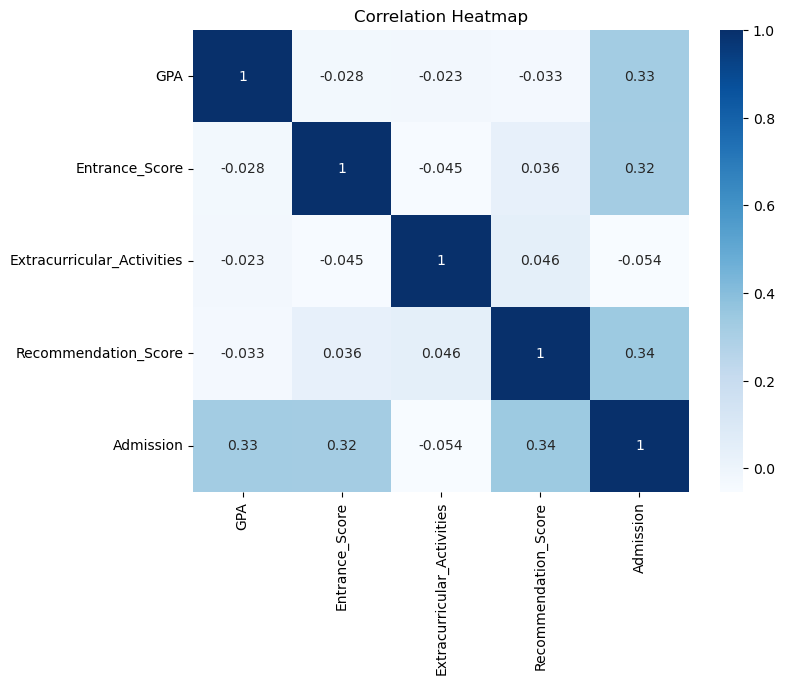

In [78]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# Define Features and Target

In [79]:
# Input variables
X = df[
    [
        'GPA',
        'Entrance_Score',
        'Extracurricular_Activities',
        'Recommendation_Score'
    ]
]

# Output variable
y = df['Admission']

# Split Dataset into Training and Testing Sets

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 800
Testing records: 200


# Train The Models 

# 1.Logistic Regression Model

In [82]:
# Create model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Calculate accuracy
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.93


#  2.Decision Tree Model

In [83]:
# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

# Calculate accuracy
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


#  3.Random Forest Model

In [84]:
# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


# Compare Model Performance

In [85]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.93
1,Decision Tree,1.00
2,Random Forest,1.00


# Visualize Model Comparison

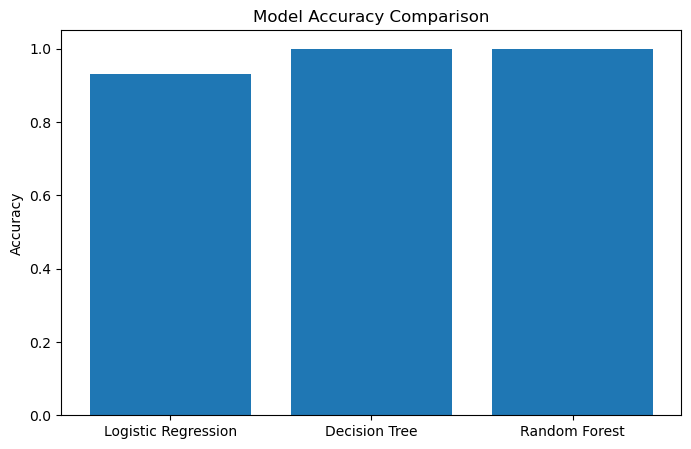

In [86]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# Select Best Model

In [87]:
best_model = rf_model

print("Best model selected: Random Forest")

Best model selected: Random Forest


# Evaluate Best Model

# By Confusion Matrix

In [88]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

cm

array([[173,   0],
       [  0,  27]])

# Confusion Matrix Visualization

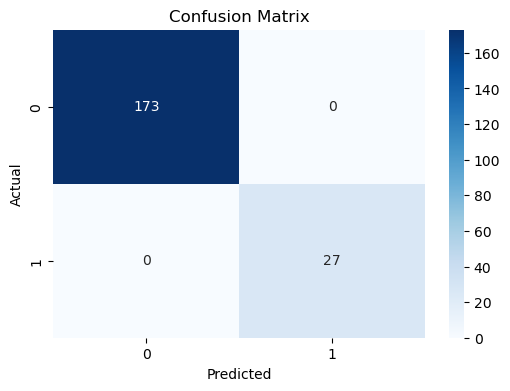

In [89]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Classification Report

In [90]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       173
           1       1.00      1.00      1.00        27

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Save the Best Model

In [91]:
pickle.dump(
    best_model,
    open("admission_model.pkl", "wb")
)

print("Model saved successfully.")

Model saved successfully.


# Test the Model with New Student Data

In [92]:
# Example student

sample_student = pd.DataFrame({
    "GPA": [3.8],
    "Entrance_Score": [85],
    "Extracurricular_Activities": [4],
    "Recommendation_Score": [8]
})

prediction = best_model.predict(sample_student)

print(prediction)

[1]


# Display Final Decision

In [93]:
if prediction[0] == 1:
    print("Student is likely to be ADMITTED")
else:
    print("Student is likely to be REJECTED")

Student is likely to be ADMITTED


In [94]:
# Total students
total_students = len(df)

# Admitted students
admitted_students = len(
    df[df["Admission"] == 1]
)

# Rejected students
rejected_students = len(
    df[df["Admission"] == 0]
)

print("Total Students:", total_students)
print("Admitted:", admitted_students)
print("Rejected:", rejected_students)

Total Students: 1000
Admitted: 126
Rejected: 874
